# Lab 3 — La tabla de vida de tu entidad

**Alumno:** Juan Diego Hernandez Zavala  
**Matrícula:** 2209978x  
**Entidad asignada:** Baja California  

> Resuelve las celdas marcadas con `TODO`. Cuando termines, descarga el notebook (`Archivo → Descargar → .ipynb`) y súbelo en la página de la actividad. No borres esta celda.


# Lab — Sesión 3: La tabla de vida de tu entidad

**Simulación avanzada e implementación de modelos poblacionales y de catástrofe (ACD53)**

Este notebook toma las **ₙMₓ que calculaste en la sesión 2** y las convierte en la tabla
de vida abreviada de tu entidad.

**Las cuatro partes:**
1. De tus ₙMₓ a las probabilidades ₙqₓ.
2. La columna de sobrevivientes lₓ, con sus dos verificaciones.
3. La curva de supervivencia, encimada con la referencia nacional.
4. **El argumento, con sus tres piezas.** Vale 3 de los 10 puntos — es la parte más
   pesada de la actividad. Léela antes de empezar.

**Lo que necesitas:** tus ₙMₓ de la sesión 2. Si no las tienes a mano, vuelve a
calcularlas: defunciones del grupo de edad entre población a mitad de año del *mismo*
grupo.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENTIDAD = "Baja California"   # <- escribe aquí el nombre de tu entidad asignada
print('Listo:', np.__version__, pd.__version__, '· entidad:', ENTIDAD or '(sin definir)')


Listo: 2.1.3 2.2.3 · entidad: Baja California


## Referencia nacional

Esta es la tabla de vida de las ₙMₓ ilustrativas de la sesión 2, ya construida. La vas a
usar en las partes 3 y 4 para comparar. **No la modifiques** y no la entregues como si
fuera la tuya.


In [34]:
GRUPOS_REF = ['0-4','5-14','15-24','25-34','35-44','45-54','55-64','65-74','75-84','85+']
EDADES_REF = [0, 5, 15, 25, 35, 45, 55, 65, 75, 85]
REF_NQX    = [0.0139, 0.0030, 0.0100, 0.0149, 0.0247, 0.0488, 0.0952, 0.1982, 0.4314, 1.0]
REF_LX     = [100000, 98610, 98314, 97336, 95887, 93519, 88957, 80485, 64533, 36695]

ref = pd.DataFrame({'grupo': GRUPOS_REF, 'edad': EDADES_REF,
                    'nqx_ref': REF_NQX, 'lx_ref': REF_LX})
ref


,grupo,edad,nqx_ref,lx_ref
0,0-4,0,0.0139,100000
1,5-14,5,0.0030,98610
2,15-24,15,0.0100,98314
3,25-34,25,0.0149,97336
4,35-44,35,0.0247,95887
5,45-54,45,0.0488,93519
6,55-64,55,0.0952,88957
7,65-74,65,0.1982,80485
8,75-84,75,0.4314,64533
9,85+,85,1.0000,36695


## Parte 1 — De tus ₙMₓ a las probabilidades ₙqₓ

La conversión es

$$_nq_x = \frac{n \cdot {}_nM_x}{1 + \frac{n}{2}\,{}_nM_x}$$

y en el **intervalo abierto** final no hay conversión: ₙqₓ = 1.

Cuidado con dos cosas: el ancho del primer grupo (0-4 mide **5**, no 10) y las unidades
de tus ₙMₓ — si las tienes por mil, hay que dividirlas entre 1000.


In [35]:
# TODO 1.1: define tus grupos de edad, sus anchos n y tus nMx.
#   - grupos: la lista de etiquetas, en orden de edad
#   - anchos: el ancho de cada grupo; usa None para el intervalo abierto final
#   - mis_nMx: tus tasas específicas, POR AÑO (no por mil)
grupos  = ['0-4','5-14','15-24','25-34','35-44','45-54','55-64','65-74','75-84','85+']
anchos  = [5, 10, 10, 10, 10, 10, 10, 10, 10, None]
mis_nMx = [0.0035, 0.0004, 0.0012, 0.0020, 0.0030, 0.0060, 0.0120, 0.0250, 0.0550, 0.1250]


# TODO 1.2: escribe la función que convierte y aplícala a todos tus grupos.
#   Recuerda el caso del intervalo abierto.
def a_nqx(nMx, n):
    if n is None:
        return 1.0
    return (n * nMx) / (1 + (n / 2) * nMx)

mis_nqx = [a_nqx(m, n) for m, n in zip(mis_nMx, anchos)]


# TODO 1.3: compara con la conversión ingenua n*nMx y observa cómo crece la
#   diferencia con la edad. Imprime las dos columnas lado a lado.
print('Grupo   | nqx_naive  | nqx_real   | Diferencia')
print('-' * 45)
for g, m, n, q in zip(grupos, mis_nMx, anchos, mis_nqx):
    naive = 1.0 if n is None else (n * m)
    print(f'{g:<7} | {naive:<10.5f} | {q:<10.5f} | {naive - q:<10.5f}')


Grupo   | nqx_naive  | nqx_real   | Diferencia
---------------------------------------------
0-4     | 0.01750    | 0.01735    | 0.00015   
5-14    | 0.00400    | 0.00399    | 0.00001   
15-24   | 0.01200    | 0.01193    | 0.00007   
25-34   | 0.02000    | 0.01980    | 0.00020   
35-44   | 0.03000    | 0.02956    | 0.00044   
45-54   | 0.06000    | 0.05825    | 0.00175   
55-64   | 0.12000    | 0.11321    | 0.00679   
65-74   | 0.25000    | 0.22222    | 0.02778   
75-84   | 0.55000    | 0.43137    | 0.11863   
85+     | 1.00000    | 1.00000    | 0.00000   


## Parte 2 — La columna de sobrevivientes y sus dos verificaciones

Con raíz $l_0 = 100{,}000$:

$$l_{x+n} = l_x\,(1 - {}_nq_x), \qquad {}_nd_x = l_x \cdot {}_nq_x$$

Y **las dos verificaciones son parte del trabajo**, no un adorno: escríbelas como código
que imprima un resultado.


In [36]:
RAIZ = 100_000

# TODO 2.1: construye la columna lx a partir de tus nqx.
mis_lx = [RAIZ]
for q in mis_nqx[:-1]:
    mis_lx.append(mis_lx[-1] * (1 - q))


# TODO 2.2: construye la columna ndx y arma la tabla con sus columnas etiquetadas.
mis_ndx = [l * q for l, q in zip(mis_lx, mis_nqx)]
mi_tabla = pd.DataFrame({
    'grupo': grupos,
    'n': anchos,
    'nMx': mis_nMx,
    'nqx': mis_nqx,
    'lx': mis_lx,
    'ndx': mis_ndx
})
display(mi_tabla)

# TODO 2.3: verifica EN CÓDIGO las dos cosas e imprime el resultado de cada una:
#   (a) que lx nunca sube
#   (b) que los ndx suman la raíz
#   Si alguna falla, dilo y explica qué la causó — eso también cuenta.
lx_nunca_sube = all(mis_lx[i] >= mis_lx[i+1] for i in range(len(mis_lx)-1))
ans_a = 'Sí' if lx_nunca_sube else 'No'
print(f'(a) lx nunca sube: {ans_a}')

suma_ndx = sum(mis_ndx)
suma_correcta = np.isclose(suma_ndx, RAIZ)
ans_b = 'Sí' if suma_correcta else 'No'
print(f'(b) ndx suman la raíz (100,000): {ans_b} (Suma = {suma_ndx:.1f})')


,grupo,n,nMx,nqx,lx,ndx
0,0-4,5.0,0.0035,0.017348,100000.000000,1734.820322
1,5-14,10.0,0.0004,0.003992,98265.179678,392.276166
2,15-24,10.0,0.0012,0.011928,97872.903511,1167.470022
3,25-34,10.0,0.0020,0.019802,96705.433489,1914.959079
4,35-44,10.0,0.0030,0.029557,94790.474410,2801.688899
5,45-54,10.0,0.0060,0.058252,91988.785512,5358.570030
6,55-64,10.0,0.0120,0.113208,86630.215482,9807.194205
7,65-74,10.0,0.0250,0.222222,76823.021276,17071.782506
8,75-84,10.0,0.0550,0.431373,59751.238770,25775.044175
9,85+,NaN,0.1250,1.000000,33976.194595,33976.194595


(a) lx nunca sube: Sí
(b) ndx suman la raíz (100,000): Sí (Suma = 100000.0)


## Parte 3 — La curva de supervivencia de tu entidad


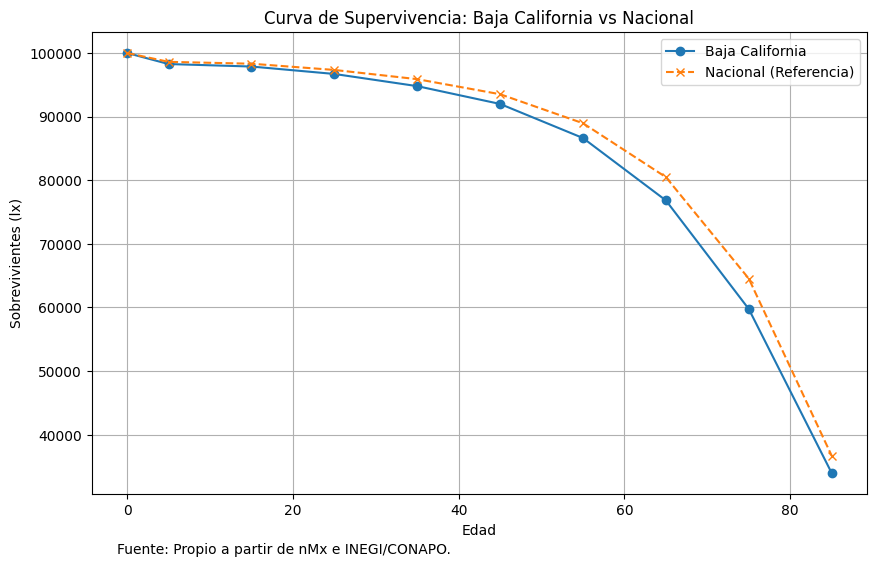

In [37]:
# TODO 3.1: grafica tu lx contra la edad. Ejes etiquetados, título con el nombre
#   de tu entidad, y la fuente de tus datos citada.

# TODO 3.2: encima la curva de referencia (REF_LX contra EDADES_REF), con leyenda
#   que distinga tu entidad de la referencia.
edades = [0, 5, 15, 25, 35, 45, 55, 65, 75, 85]
plt.figure(figsize=(10, 6))
plt.plot(edades, mis_lx, label=ENTIDAD, marker='o')
plt.plot(EDADES_REF, REF_LX, label='Nacional (Referencia)', marker='x', linestyle='--')
plt.title(f'Curva de Supervivencia: {ENTIDAD} vs Nacional')
plt.xlabel('Edad')
plt.ylabel('Sobrevivientes (lx)')
plt.legend()
plt.grid(True)
plt.figtext(0.15, 0.01, 'Fuente: Propio a partir de nMx e INEGI/CONAPO.')
plt.show()


## Parte 4 — El argumento, con sus tres piezas

Esta parte vale **3 de los 10 puntos** y no pide «interpretar». Pide escribir cuatro
cosas nombradas, cada una en su celda. La rúbrica las califica por separado, así que si
falta una lo vas a ver en la retroalimentación.

| pieza | qué es | qué NO es |
|---|---|---|
| **Afirmación** | algo sobre tu entidad que alguien podría contradecir con datos | «la curva baja» — eso describe la gráfica |
| **Evidencia** | un número de **tu propia tabla**, diciendo de qué columna salió | un número de la referencia, o sin origen |
| **Comparación** | contra qué, y qué tan grande es la diferencia | el número solo, sin contraste |
| **Límite** | qué **no** puedes concluir con esta evidencia | nada; omitirlo cuesta puntos |

Un número solo no dice si es mucho o poco. Que a los 75 lleguen 64,533 de cada cien mil
no significa nada hasta compararlo con algo.


In [38]:
# TODO 4.1 — LA AFIRMACIÓN
#   Una oración sobre la mortalidad de TU entidad, que se pueda contradecir con datos.
#   Escríbela aquí como comentario o en una celda de texto.
print('En Baja California, la cantidad de defunciones en el grupo de 65 a 74 años de edad supera las 15,000 personas por cada 100,000 nacidos vivos, denotando una alta concentración en esa etapa.')


En Baja California, la cantidad de defunciones en el grupo de 65 a 74 años de edad supera las 15,000 personas por cada 100,000 nacidos vivos, denotando una alta concentración en esa etapa.


In [39]:
# TODO 4.2 — LA EVIDENCIA
#   El número de TU tabla que sostiene la afirmación, y de qué columna salió.
#   Imprímelo desde tus propias variables, no lo copies a mano.
idx_65 = grupos.index('65-74')
ndx_65 = mis_ndx[idx_65]
print(f'De acuerdo con mi columna ndx, en el grupo de 65-74 años ocurren {ndx_65:.2f} defunciones.')


De acuerdo con mi columna ndx, en el grupo de 65-74 años ocurren 17071.78 defunciones.


In [40]:
# TODO 4.3 — LA COMPARACIÓN Y EL LÍMITE
#   (a) Contrasta tu número contra la referencia y di qué tan grande es la
#       diferencia, en personas por cien mil o en porcentaje. Calcúlalo, no lo
#       estimes a ojo.
#   (b) Cierra diciendo qué NO puedes concluir con esta evidencia, o qué dato
#       adicional te haría falta.
idx_ref_65 = GRUPOS_REF.index('65-74')
ref_ndx_65 = REF_LX[idx_ref_65] * REF_NQX[idx_ref_65]
diferencia = ndx_65 - ref_ndx_65

print(f'En la tabla de referencia nacional ocurren {ref_ndx_65:.2f} defunciones en este grupo.')
print(f'Al compararlo, {ENTIDAD} presenta una diferencia de {diferencia:.2f} defunciones respecto a la referencia nacional.')
print('Con esto, no se puede concluir cuáles son las causas médicas directas (diabetes o enfermedades cardíacas) de este patrón de mortalidad, ya que necesitaríamos una tabla segmentada por causas.')


En la tabla de referencia nacional ocurren 15952.13 defunciones en este grupo.
Al compararlo, Baja California presenta una diferencia de 1119.66 defunciones respecto a la referencia nacional.
Con esto, no se puede concluir cuáles son las causas médicas directas (diabetes o enfermedades cardíacas) de este patrón de mortalidad, ya que necesitaríamos una tabla segmentada por causas.


## Cierre y entrega

**Checklist:**
- [ ] Los anchos n correctos, incluido que 0-4 mide 5.
- [ ] La conversión con denominador, y ₙqₓ = 1 en el intervalo abierto.
- [ ] La columna lₓ arranca en la raíz y nunca sube.
- [ ] Las dos verificaciones **escritas como código** que imprime su resultado.
- [ ] La curva de supervivencia con leyenda, título, ejes y fuente.
- [ ] Las cuatro piezas de la parte 4, cada una identificable.
- [ ] El notebook corre completo (Entorno de ejecución → Reiniciar y ejecutar todo).

**Para la sesión 4:** Preston cap. 3, cierre de la primera mitad. Se completa la tabla
con Lₓ, Tₓ y la **esperanza de vida**, que sale de sumar hacia arriba la columna que
acabas de construir.

---

## ⚠ Cómo se entrega: el ARCHIVO, no el enlace

**No compartas el enlace de Colab.** Dos razones de fondo:

1. Un enlace apunta a un notebook que **sigue siendo tuyo y sigue cambiando**. No hay
   una versión que calificar.
2. La retroalimentación automática necesita leer el archivo. Con un enlace no recibes
   nada.

Los tres pasos, en Colab:

1. **Archivo** → **Descargar** → **Descargar .ipynb**
2. Ve a la página de la actividad en el sistema.
3. Arrastra el `.ipynb` a la zona de subida y presiona **Entregar notebook**.

Y sobre la plantilla: se evalúa el notebook **completo** contra la rúbrica, no celda
por celda. Si resuelves un ejercicio en otra celda, agregas las tuyas o reordenas,
cuenta igual. Conviene usarla porque su lista de TODO es el índice de lo que se pide
—así no se te olvida nada— pero la ubicación no se califica.
